# CartPole — Trajectory Optimization

SeapoPym is a **differentiable simulator**: JAX's automatic differentiation can compute gradients _through_ the entire physics simulation. This example demonstrates this capability on the classic **CartPole** (inverted pendulum on a cart) problem, based on the equations of motion from [Barto, Sutton & Anderson (1983)](https://ieeexplore.ieee.org/document/6313077).

The original paper solved CartPole with neuron-like adaptive elements (early reinforcement learning). Here, we take a fundamentally different approach: instead of learning a policy through trial and error, we **optimize the complete force sequence** $F(t)$ by gradient descent _through_ the physics equations. The simulator is fully differentiable — so we get exact gradients in one pass.

$$\text{minimize}_{F(t)} \sum_t \left[ w_\theta \, \theta(t)^2 + w_x \, x(t)^2 + w_F \, F(t)^2 \right]$$


In [1]:
import time

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import optax
import xarray as xr

from seapopym.blueprint import Blueprint, Config, functional
from seapopym.compiler import compile_model
from seapopym.engine.run import run
from seapopym.engine.step import build_step_fn

PALETTE = ["#1B4965", "#62B6CB", "#E8833A", "#5FA8D3"]
plt.rcParams.update({"figure.facecolor": "white", "axes.facecolor": "white", "axes.grid": True, "grid.alpha": 0.3})

## 1. Define the Physics

The CartPole dynamics are described by four state variables: cart position $x$, cart velocity $\dot{x}$, pole angle $\theta$ (0 = upright), and angular velocity $\dot{\theta}$. A horizontal force $F$ is applied to the cart.

We decompose the physics into **three functions**, mirroring the actual data flow:

1. **Velocity passthrough** — $dx/dt = \dot{x}$ and $d\theta/dt = \dot{\theta}$ (identity: velocity _is_ the derivative of position)
2. **Angular acceleration** — from the pendulum equation:
   $$\ddot{\theta} = \frac{g \sin\theta + \cos\theta \left(\frac{-F - m_p l \dot{\theta}^2 \sin\theta}{m_c + m_p}\right)}{l \left(\frac{4}{3} - \frac{m_p \cos^2\theta}{m_c + m_p}\right)}$$
3. **Linear acceleration** — depends on $\ddot{\theta}$ (computed in step 2):
   $$\ddot{x} = \frac{F + m_p l \left(\dot{\theta}^2 \sin\theta - \ddot{\theta} \cos\theta\right)}{m_c + m_p}$$

This decomposition makes the **data flow explicit** in SeapoPym's process DAG: the angular acceleration feeds into the linear acceleration.


In [2]:
@functional(
    name="cp:velocity",
    units={
        "x_dot": "m/s",
        "theta_dot": "rad/s",
        "dx_dt": "m/s",
        "dtheta_dt": "rad/s",
    },
    outputs=("dx_dt", "dtheta_dt"),
)
def velocity(x_dot, theta_dot):
    """Identity: velocity is the time derivative of position."""
    return x_dot, theta_dot


@functional(
    name="cp:angular_accel",
    units={
        "theta": "rad",
        "theta_dot": "rad/s",
        "force": "N",
        "gravity": "m/s^2",
        "mass_cart": "kg",
        "mass_pole": "kg",
        "half_length": "m",
        "return": "rad/s^2",
    },
)
def angular_accel(theta, theta_dot, force, gravity, mass_cart, mass_pole, half_length):
    """Pendulum angular acceleration from Barto et al. (1983)."""
    total_mass = mass_cart + mass_pole
    cos_theta = jnp.cos(theta)
    sin_theta = jnp.sin(theta)
    return (
        gravity * sin_theta + cos_theta * ((-force - mass_pole * half_length * theta_dot**2 * sin_theta) / total_mass)
    ) / (half_length * (4.0 / 3.0 - (mass_pole * cos_theta**2) / total_mass))


@functional(
    name="cp:linear_accel",
    units={
        "theta": "rad",
        "theta_dot": "rad/s",
        "theta_ddot": "rad/s^2",
        "force": "N",
        "mass_cart": "kg",
        "mass_pole": "kg",
        "half_length": "m",
        "return": "m/s^2",
    },
)
def linear_accel(theta, theta_dot, theta_ddot, force, mass_cart, mass_pole, half_length):
    """Cart linear acceleration — depends on angular acceleration."""
    total_mass = mass_cart + mass_pole
    return (
        force + mass_pole * half_length * (theta_dot**2 * jnp.sin(theta) - theta_ddot * jnp.cos(theta))
    ) / total_mass

## 2. Build the Blueprint

The Blueprint declares 4 state variables, 4 physical constants, and the **force** as a time-indexed parameter (`dims: [T]`). This is the key feature: `force` has a value at each timestep, and because it flows through JAX's `lax.scan` as a differentiable input, we can compute $\partial \text{loss} / \partial F(t)$ for every $t$.

The process DAG has **3 steps** with an explicit dependency: `angular_accel` produces `derived.theta_ddot`, which `linear_accel` consumes.


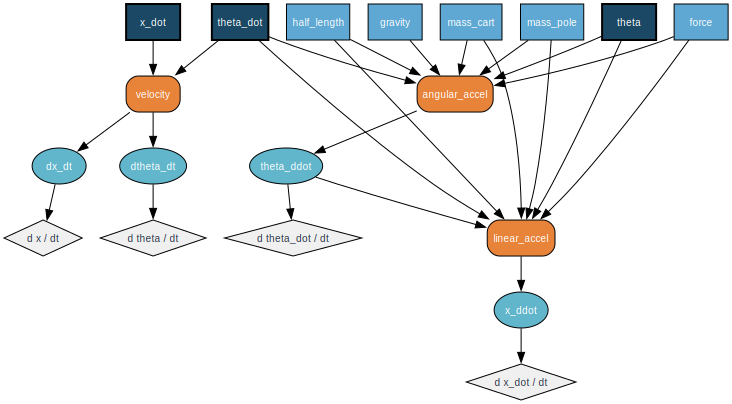

In [3]:
blueprint = Blueprint.from_dict(
    {
        "id": "cartpole",
        "version": "1.0",
        "declarations": {
            "state": {
                "x": {"units": "m", "dims": ["Y", "X"]},
                "x_dot": {"units": "m/s", "dims": ["Y", "X"]},
                "theta": {"units": "rad", "dims": ["Y", "X"]},
                "theta_dot": {"units": "rad/s", "dims": ["Y", "X"]},
            },
            "parameters": {
                "gravity": {"units": "m/s^2"},
                "mass_cart": {"units": "kg"},
                "mass_pole": {"units": "kg"},
                "half_length": {"units": "m"},
                "force": {"units": "N", "dims": ["T"]},
            },
            "forcings": {},
            "derived": {
                "dx_dt": {"units": "m/s"},
                "dtheta_dt": {"units": "rad/s"},
                "theta_ddot": {"units": "rad/s^2"},
                "x_ddot": {"units": "m/s^2"},
            },
        },
        "process": [
            {
                "func": "cp:velocity",
                "inputs": {
                    "x_dot": "state.x_dot",
                    "theta_dot": "state.theta_dot",
                },
                "outputs": {
                    "dx_dt": "derived.dx_dt",
                    "dtheta_dt": "derived.dtheta_dt",
                },
            },
            {
                "func": "cp:angular_accel",
                "inputs": {
                    "theta": "state.theta",
                    "theta_dot": "state.theta_dot",
                    "force": "parameters.force",
                    "gravity": "parameters.gravity",
                    "mass_cart": "parameters.mass_cart",
                    "mass_pole": "parameters.mass_pole",
                    "half_length": "parameters.half_length",
                },
                "outputs": {"return": "derived.theta_ddot"},
            },
            {
                "func": "cp:linear_accel",
                "inputs": {
                    "theta": "state.theta",
                    "theta_dot": "state.theta_dot",
                    "theta_ddot": "derived.theta_ddot",
                    "force": "parameters.force",
                    "mass_cart": "parameters.mass_cart",
                    "mass_pole": "parameters.mass_pole",
                    "half_length": "parameters.half_length",
                },
                "outputs": {"return": "derived.x_ddot"},
            },
        ],
        "tendencies": {
            "x": [{"source": "derived.dx_dt"}],
            "x_dot": [{"source": "derived.x_ddot"}],
            "theta": [{"source": "derived.dtheta_dt"}],
            "theta_dot": [{"source": "derived.theta_ddot"}],
        },
    }
)

blueprint.to_graphviz()

## 3. Configure & Compile

Standard CartPole parameters: 1 kg cart, 0.1 kg pole, 0.5 m half-length, 9.81 m/s² gravity.

The initial state has the pole tilted at **0.2 rad (~11.5°)** — the optimizer must find a force sequence that brings it back upright.

We simulate **2 seconds** at **dt = 0.001s** (2000 timesteps). The small timestep keeps Euler explicit integration numerically stable for this stiff system.


In [4]:
DT = 0.001  # seconds
DURATION = 2.0  # seconds
N_STEPS = int(DURATION / DT)

config = Config(
    parameters={
        "gravity": xr.DataArray(9.81),
        "mass_cart": xr.DataArray(1.0),
        "mass_pole": xr.DataArray(0.1),
        "half_length": xr.DataArray(0.5),
        "force": xr.DataArray(np.zeros(N_STEPS), dims=["T"]),
    },
    forcings={},
    initial_state={
        "x": xr.DataArray(np.array([[0.0]]), dims=["Y", "X"]),
        "x_dot": xr.DataArray(np.array([[0.0]]), dims=["Y", "X"]),
        "theta": xr.DataArray(np.array([[0.2]]), dims=["Y", "X"]),
        "theta_dot": xr.DataArray(np.array([[0.0]]), dims=["Y", "X"]),
    },
    execution={
        "time_start": "2000-01-01",
        "time_end": "2000-01-01T00:00:02",
        "dt": f"{DT}s",
    },
)

model = compile_model(blueprint, config)
print(f"Compiled: {model.n_timesteps} timesteps, dt = {model.dt}s")
print(f"Time-indexed parameters: {model.time_indexed_params}")
print(f"Clamp map: {model.clamp_map}  (empty = no clamping, states can go negative)")

Compiled: 2000 timesteps, dt = 0.001s
Time-indexed parameters: {'force'}
Clamp map: {}  (empty = no clamping, states can go negative)


In [5]:
step_fn = build_step_fn(model, export_variables=["x", "x_dot", "theta", "theta_dot"])

t0 = time.perf_counter()
_, outputs_uncontrolled = run(step_fn, model, dict(model.state), dict(model.parameters))
elapsed = time.perf_counter() - t0

time_axis = np.arange(model.n_timesteps) * DT
theta_unc = np.asarray(outputs_uncontrolled["theta"][:, 0, 0])
x_unc = np.asarray(outputs_uncontrolled["x"][:, 0, 0])

print(f"Simulated {model.n_timesteps} steps in {elapsed:.3f}s")
print(f"Final theta: {theta_unc[-1]:.3f} rad")
print(f"Final x:     {x_unc[-1]:.3f} m")

Simulated 2000 steps in 0.042s
Final theta: 6.147 rad
Final x:     0.015 m


## 4. Optimize the Force Sequence

We define a cost function that penalizes:

- **Pole deviation** from vertical ($\theta^2$, weight 1.0)
- **Cart drift** from center ($x^2$, weight 0.1)
- **Control effort** ($F^2$, weight 0.001 — regularization)

Then we compute `jax.grad(loss)` with respect to all parameters — including the **2000-dimensional** force vector — and optimize with **Adam** (Optax). The loss drops by two orders of magnitude in the first 50 steps; the remaining iterations refine the trajectory.


In [6]:
W_THETA = 1.0  # Keep pole upright (primary objective)
W_X = 0.1  # Keep cart centered (secondary)
W_F = 0.001  # Regularize force (avoid extreme commands)


def loss_fn(params):
    """Cost function: simulate full trajectory, return scalar loss."""
    _, out = run(step_fn, model, dict(model.state), params)
    theta = out["theta"][:, 0, 0]
    x = out["x"][:, 0, 0]
    return W_THETA * jnp.mean(theta**2) + W_X * jnp.mean(x**2) + W_F * jnp.mean(params["force"] ** 2)


value_and_grad_fn = jax.jit(jax.value_and_grad(loss_fn))

# Warm-up JIT compilation
_ = value_and_grad_fn(dict(model.parameters))
print(f"JIT compiled — forward + backward pass through {model.n_timesteps} timesteps")

JIT compiled — forward + backward pass through 2000 timesteps


In [7]:
N_OPT_STEPS = 500
LR = 1e-2

optimizer = optax.adam(LR)
params = dict(model.parameters)
opt_state = optimizer.init(params)

loss_history = []

t0 = time.perf_counter()
for i in range(N_OPT_STEPS):
    loss, grads = value_and_grad_fn(params)
    updates, opt_state = optimizer.update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)
    loss_history.append(float(loss))
    if i % 50 == 0:
        print(f"  step {i:3d}: loss = {loss:.4f}")

elapsed = time.perf_counter() - t0
print(f"\nOptimized {N_OPT_STEPS} steps in {elapsed:.1f}s")
print(f"Loss: {loss_history[0]:.2f} \u2192 {loss_history[-1]:.4f}")

  step   0: loss = 16.5400
  step  50: loss = 0.2303
  step 100: loss = 0.1618
  step 150: loss = 0.1377
  step 200: loss = 0.1111
  step 250: loss = 0.0829
  step 300: loss = 0.0669
  step 350: loss = 0.0626
  step 400: loss = 0.0598
  step 450: loss = 0.0572

Optimized 500 steps in 0.5s
Loss: 16.54 → 0.0545


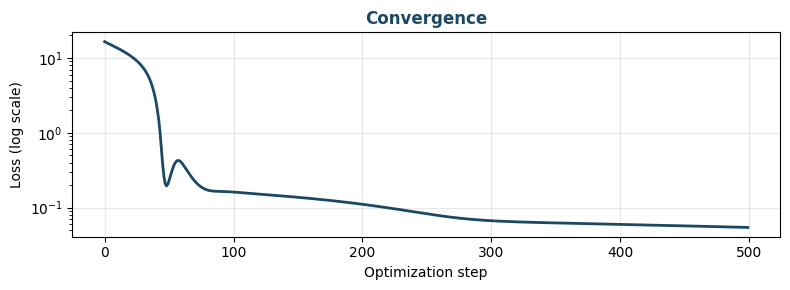

In [8]:
fig, ax = plt.subplots(figsize=(8, 3))
ax.semilogy(loss_history, color=PALETTE[0], linewidth=2)
ax.set_xlabel("Optimization step")
ax.set_ylabel("Loss (log scale)")
ax.set_title("Convergence", fontweight="bold", color=PALETTE[0])
plt.tight_layout()
plt.show()

## 5. Results — Optimized Trajectory

Let's simulate with the optimized force sequence and compare to the uncontrolled case — first as an animation, then with detailed plots.


In [9]:
_, outputs_opt = run(step_fn, model, dict(model.state), params)

theta_opt = np.asarray(outputs_opt["theta"][:, 0, 0])
x_opt = np.asarray(outputs_opt["x"][:, 0, 0])
force_opt = np.asarray(params["force"])

Saved 40 frames at 10 fps — copied to ../assets/cartpole_comparison.gif



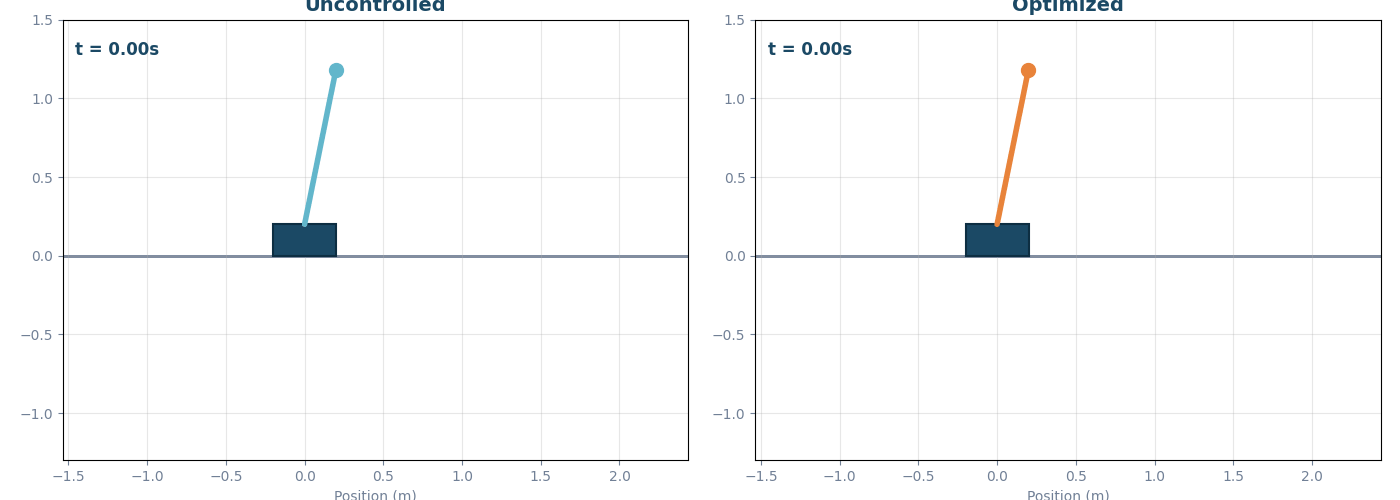

In [10]:
import base64
import shutil

from IPython.display import HTML
from matplotlib.animation import FuncAnimation, PillowWriter

POLE_LEN = 1.0  # 2 * half_length
CART_W, CART_H = 0.4, 0.2
SIM_FPS = 20  # frames per second of simulation time
GIF_FPS = 10  # frames per second in the gif

frame_step = max(1, int(1.0 / (SIM_FPS * DT)))
frame_indices = np.arange(0, model.n_timesteps, frame_step)
n_frames = len(frame_indices)

# Axis limits from both trajectories
all_x = np.concatenate([x_unc[frame_indices], x_opt[frame_indices]])
x_lo, x_hi = all_x.min() - 1.5, all_x.max() + 1.5

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor("white")

elements = []
for ax, title, x_arr, theta_arr, color in [
    (axes[0], "Uncontrolled", x_unc, theta_unc, PALETTE[1]),
    (axes[1], "Optimized", x_opt, theta_opt, PALETTE[2]),
]:
    ax.set_aspect("equal")
    ax.set_xlim(x_lo, x_hi)
    ax.set_ylim(-1.3, 1.5)
    ax.plot([x_lo, x_hi], [0, 0], color="#718096", linewidth=2, zorder=0)
    ax.set_title(title, fontsize=14, fontweight="bold", color=PALETTE[0])
    ax.set_xlabel("Position (m)", color="#718096")
    ax.tick_params(colors="#718096")
    ax.set_facecolor("white")
    ax.grid(True, alpha=0.3)

    cart = plt.Rectangle((0, 0), CART_W, CART_H, fc="#1B4965", ec="#0d2e42", lw=1.5, zorder=2)
    ax.add_patch(cart)
    (pole_line,) = ax.plot([], [], color=color, linewidth=4, solid_capstyle="round", zorder=3)
    (pole_tip,) = ax.plot([], [], "o", color=color, markersize=10, zorder=4)
    time_text = ax.text(0.02, 0.92, "", transform=ax.transAxes, fontsize=12, color=PALETTE[0], fontweight="bold")
    elements.append((cart, pole_line, pole_tip, time_text, x_arr, theta_arr))

plt.tight_layout()


def animate(frame_idx):
    artists = []
    i = frame_indices[frame_idx]
    t = i * DT
    for cart, pole_line, pole_tip, time_text, x_arr, theta_arr in elements:
        cx = float(x_arr[i])
        th = float(theta_arr[i])
        cart.set_x(cx - CART_W / 2)
        cart.set_y(0)
        px, py = cx, CART_H
        tx = px + POLE_LEN * np.sin(th)
        ty = py + POLE_LEN * np.cos(th)
        pole_line.set_data([px, tx], [py, ty])
        pole_tip.set_data([tx], [ty])
        time_text.set_text(f"t = {t:.2f}s")
        artists.extend([cart, pole_line, pole_tip, time_text])
    return artists


gif_path = "cartpole_comparison.gif"
anim = FuncAnimation(fig, animate, frames=n_frames, interval=1000 / GIF_FPS, blit=True)
anim.save(gif_path, writer=PillowWriter(fps=GIF_FPS))
plt.close()

# Move to docs/assets for mkdocs
assets_path = "../assets/cartpole_comparison.gif"
shutil.copy2(gif_path, assets_path)
print(f"Saved {n_frames} frames at {GIF_FPS} fps \u2014 copied to {assets_path}")

# Display inline as HTML base64 (works in mkdocs-jupyter)
with open(gif_path, "rb") as f:
    gif_b64 = base64.b64encode(f.read()).decode()
HTML(f'<img src="data:image/gif;base64,{gif_b64}" alt="CartPole comparison" style="width:100%">')

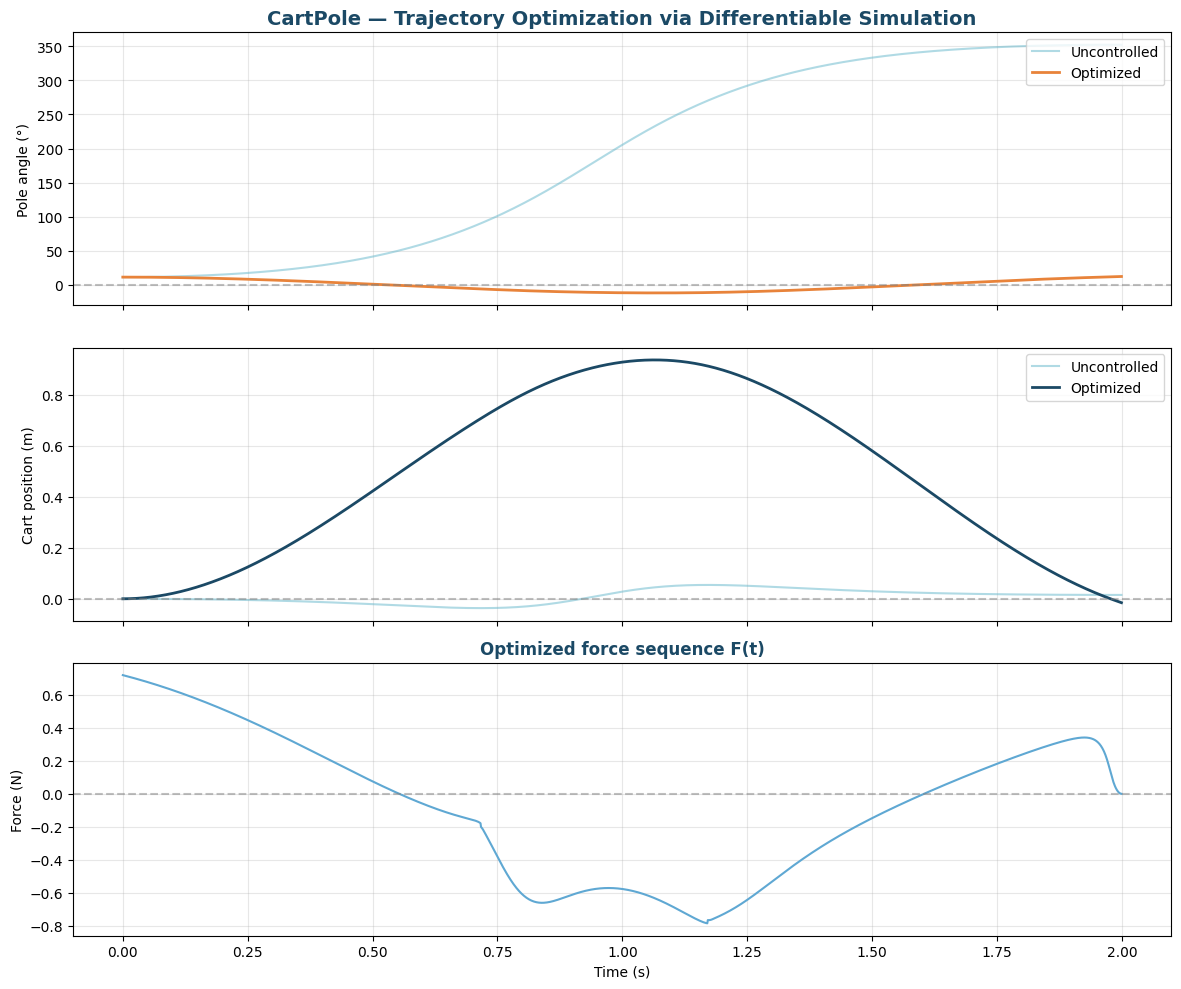

In [11]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# Panel 1: Pole angle
axes[0].plot(time_axis, np.degrees(theta_unc), color=PALETTE[1], linewidth=1.5, alpha=0.5, label="Uncontrolled")
axes[0].plot(time_axis, np.degrees(theta_opt), color=PALETTE[2], linewidth=2, label="Optimized")
axes[0].axhline(0, color="gray", linestyle="--", alpha=0.5)
axes[0].set_ylabel("Pole angle (\u00b0)")
axes[0].set_title(
    "CartPole \u2014 Trajectory Optimization via Differentiable Simulation",
    fontsize=14,
    fontweight="bold",
    color=PALETTE[0],
)
axes[0].legend(loc="upper right")

# Panel 2: Cart position
axes[1].plot(time_axis, x_unc, color=PALETTE[1], linewidth=1.5, alpha=0.5, label="Uncontrolled")
axes[1].plot(time_axis, x_opt, color=PALETTE[0], linewidth=2, label="Optimized")
axes[1].axhline(0, color="gray", linestyle="--", alpha=0.5)
axes[1].set_ylabel("Cart position (m)")
axes[1].legend(loc="upper right")

# Panel 3: Applied force
axes[2].plot(time_axis, force_opt, color=PALETTE[3], linewidth=1.5)
axes[2].axhline(0, color="gray", linestyle="--", alpha=0.5)
axes[2].set_xlabel("Time (s)")
axes[2].set_ylabel("Force (N)")
axes[2].set_title("Optimized force sequence F(t)", fontweight="bold", color=PALETTE[0])

plt.tight_layout()
plt.show()

## Summary

This example demonstrates that **SeapoPym works far beyond oceanography** — any dynamical system expressible as ODEs can be declared as a Blueprint, compiled, and optimized through.

| What         | How                                                               |
| ------------ | ----------------------------------------------------------------- |
| Physics      | 3 `@functional` functions (velocity, angular accel, linear accel) |
| Model        | 4 states, 4 constants, 1 **time-indexed parameter** `force[T]`    |
| Optimization | `jax.grad` through 2000 timesteps of `lax.scan` — 500 Adam steps  |
| Result       | Loss drops 99% in ~50 steps, then refines over ~400 more          |

### Key feature: time-indexed parameters

The `force` parameter is declared with `dims: ["T"]`. SeapoPym's engine automatically:

1. Detects it at compile time (`model.time_indexed_params`)
2. Passes it through `lax.scan`'s `xs` input (not the carry)
3. Makes it **fully differentiable** — `jax.grad` returns per-timestep gradients

This is fundamentally different from classical RL, which treats the simulator as a black box. Here, the physics is **declared explicitly** in the Blueprint DAG, and optimization happens by direct gradient descent through the equations of motion.

### Limitations & next steps

This open-loop approach optimizes the _entire_ force trajectory at once. It works well for short horizons (2s here), but for longer simulations the gradient signal degrades — early timesteps have vanishing influence on the final loss. A natural extension is **Model Predictive Control (MPC)**: optimize only a short sliding window, apply the first few steps, re-optimize from the new state. SeapoPym's `run()` function already supports this pattern since it accepts arbitrary initial states.
